# Bank Term-Deposit Subscription Prediction
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

In [106]:
sns.set_theme(style='whitegrid', context='notebook', palette='mako')

## 2. Loading the Data

In [7]:
df = pd.read_csv(r'C:\Users\user\Downloads\archive (1)\bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.shape

(41188, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 3. Data Cleaning
### 3.1 Column Names and Missing Values

In [12]:
df.columns = df.columns.str.replace('.', '_', regex=False)
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [13]:
df.isna().sum().sum()

np.int64(0)

### 3.2 Duplicates

In [14]:
df.duplicated().sum()

np.int64(12)

In [24]:
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [25]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### 3.3 Target Variable and Class Balance

In [44]:
df = df.rename(columns={'y':'subscribed'})

In [45]:
df['subscribed'].value_counts()

subscribed
no     36537
yes     4639
Name: count, dtype: int64

In [46]:
(df['subscribed'].value_counts(normalize=True) * 100).round(3)

subscribed
no     88.734
yes    11.266
Name: proportion, dtype: float64

### 3.4 The pdays Placeholder (999)

In [58]:
df['contacted_before'] = (df['pdays'] != 999).astype(int)
df['contacted_before'].unique()

array([0, 1])

In [59]:
df.loc[(df['pdays'] == 999), 'pdays'] = 0
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed,contacted_before
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [62]:
df['pdays'].unique()

array([ 0,  6,  4,  3,  5,  1, 10,  7,  8,  9, 11,  2, 12, 13, 14, 15, 16,
       21, 17, 18, 22, 25, 26, 19, 27, 20])

## 4. Exploratory Data Analysis
### 4.1 Column Types and Categories

In [63]:
number_cols = df.select_dtypes(include=[int, float]).columns.to_list()
number_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'contacted_before']

In [65]:
object_cols = df.select_dtypes(include=object).columns.to_list()
object_cols.remove('subscribed')
object_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [91]:
df['education'] = df['education'].str.replace('.', '_', regex=False)
for col in object_cols:
    uniques = df[col].unique()
    no_of_uniques = df[col].nunique()
    print(f'{col:15s} ....     no. of unique values: {no_of_uniques:3d}       ....        samples: {uniques[:5]}')

job             ....     no. of unique values:  12       ....        samples: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician']
marital         ....     no. of unique values:   4       ....        samples: ['married' 'single' 'divorced' 'unknown']
education       ....     no. of unique values:   8       ....        samples: ['basic_4y' 'high_school' 'basic_6y' 'basic_9y' 'professional_course']
default         ....     no. of unique values:   3       ....        samples: ['no' 'unknown' 'yes']
housing         ....     no. of unique values:   3       ....        samples: ['no' 'yes' 'unknown']
loan            ....     no. of unique values:   3       ....        samples: ['no' 'yes' 'unknown']
contact         ....     no. of unique values:   2       ....        samples: ['telephone' 'cellular']
month           ....     no. of unique values:  10       ....        samples: ['may' 'jun' 'jul' 'aug' 'oct']
day_of_week     ....     no. of unique values:   5       ....        samples

### 4.2 Numeric Summary and Averages by Outcome

In [78]:
df[number_cols].describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,contacted_before
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,0.221294,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.036793
std,10.42068,259.305321,2.770318,1.349065,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.188256
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,0.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,0.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [80]:
df.groupby('subscribed')[number_cols].mean().round(2).T

subscribed,no,yes
age,39.91,40.91
duration,220.87,553.26
campaign,2.63,2.05
pdays,0.09,1.23
previous,0.13,0.49
emp_var_rate,0.25,-1.23
cons_price_idx,93.60,93.35
cons_conf_idx,-40.59,-39.79
euribor3m,3.81,2.12
nr_employed,5176.17,5095.12


### 4.3 Target Encoding and Correlations

In [86]:
if df['subscribed'].dtypes == object:
    df['subscribed'] = df['subscribed'].map({'yes': 1, 'no':0})
    
df['subscribed'].dtypes

dtype('int64')

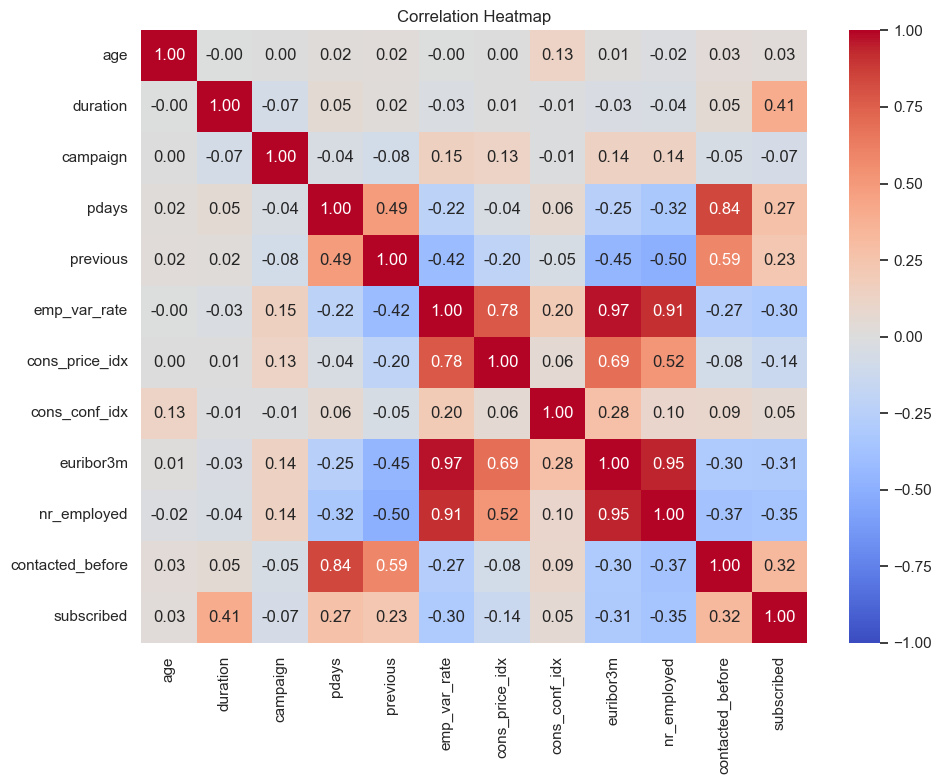

In [107]:
correlation_cols = number_cols + ['subscribed']
correlation = df[correlation_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 4.4 Subscription Rate by Category

In [99]:
for col in object_cols:
    group = df.groupby(col)['subscribed'].agg(['count', 'mean']).sort_values('count', ascending=False)
    group['mean'] = (group['mean'] * 100).round(2)
    print(f'......{col}......')
    print(group)

......job......
               count   mean
job                        
admin.         10419  12.97
blue-collar     9253   6.90
technician      6739  10.83
services        3967   8.14
management      2924  11.22
retired         1718  25.26
entrepreneur    1456   8.52
self-employed   1421  10.49
housemaid       1060  10.00
unemployed      1014  14.20
student          875  31.43
unknown          330  11.21
......marital......
          count   mean
marital               
married   24921  10.16
single    11564  14.01
divorced   4611  10.32
unknown      80  15.00
......education......
                     count   mean
education                        
university_degree    12164  13.72
high_school           9512  10.84
basic_9y              6045   7.82
professional_course   5240  11.35
basic_4y              4176  10.25
basic_6y              2291   8.21
unknown               1730  14.51
illiterate              18  22.22
......default......
         count   mean
default              
no      

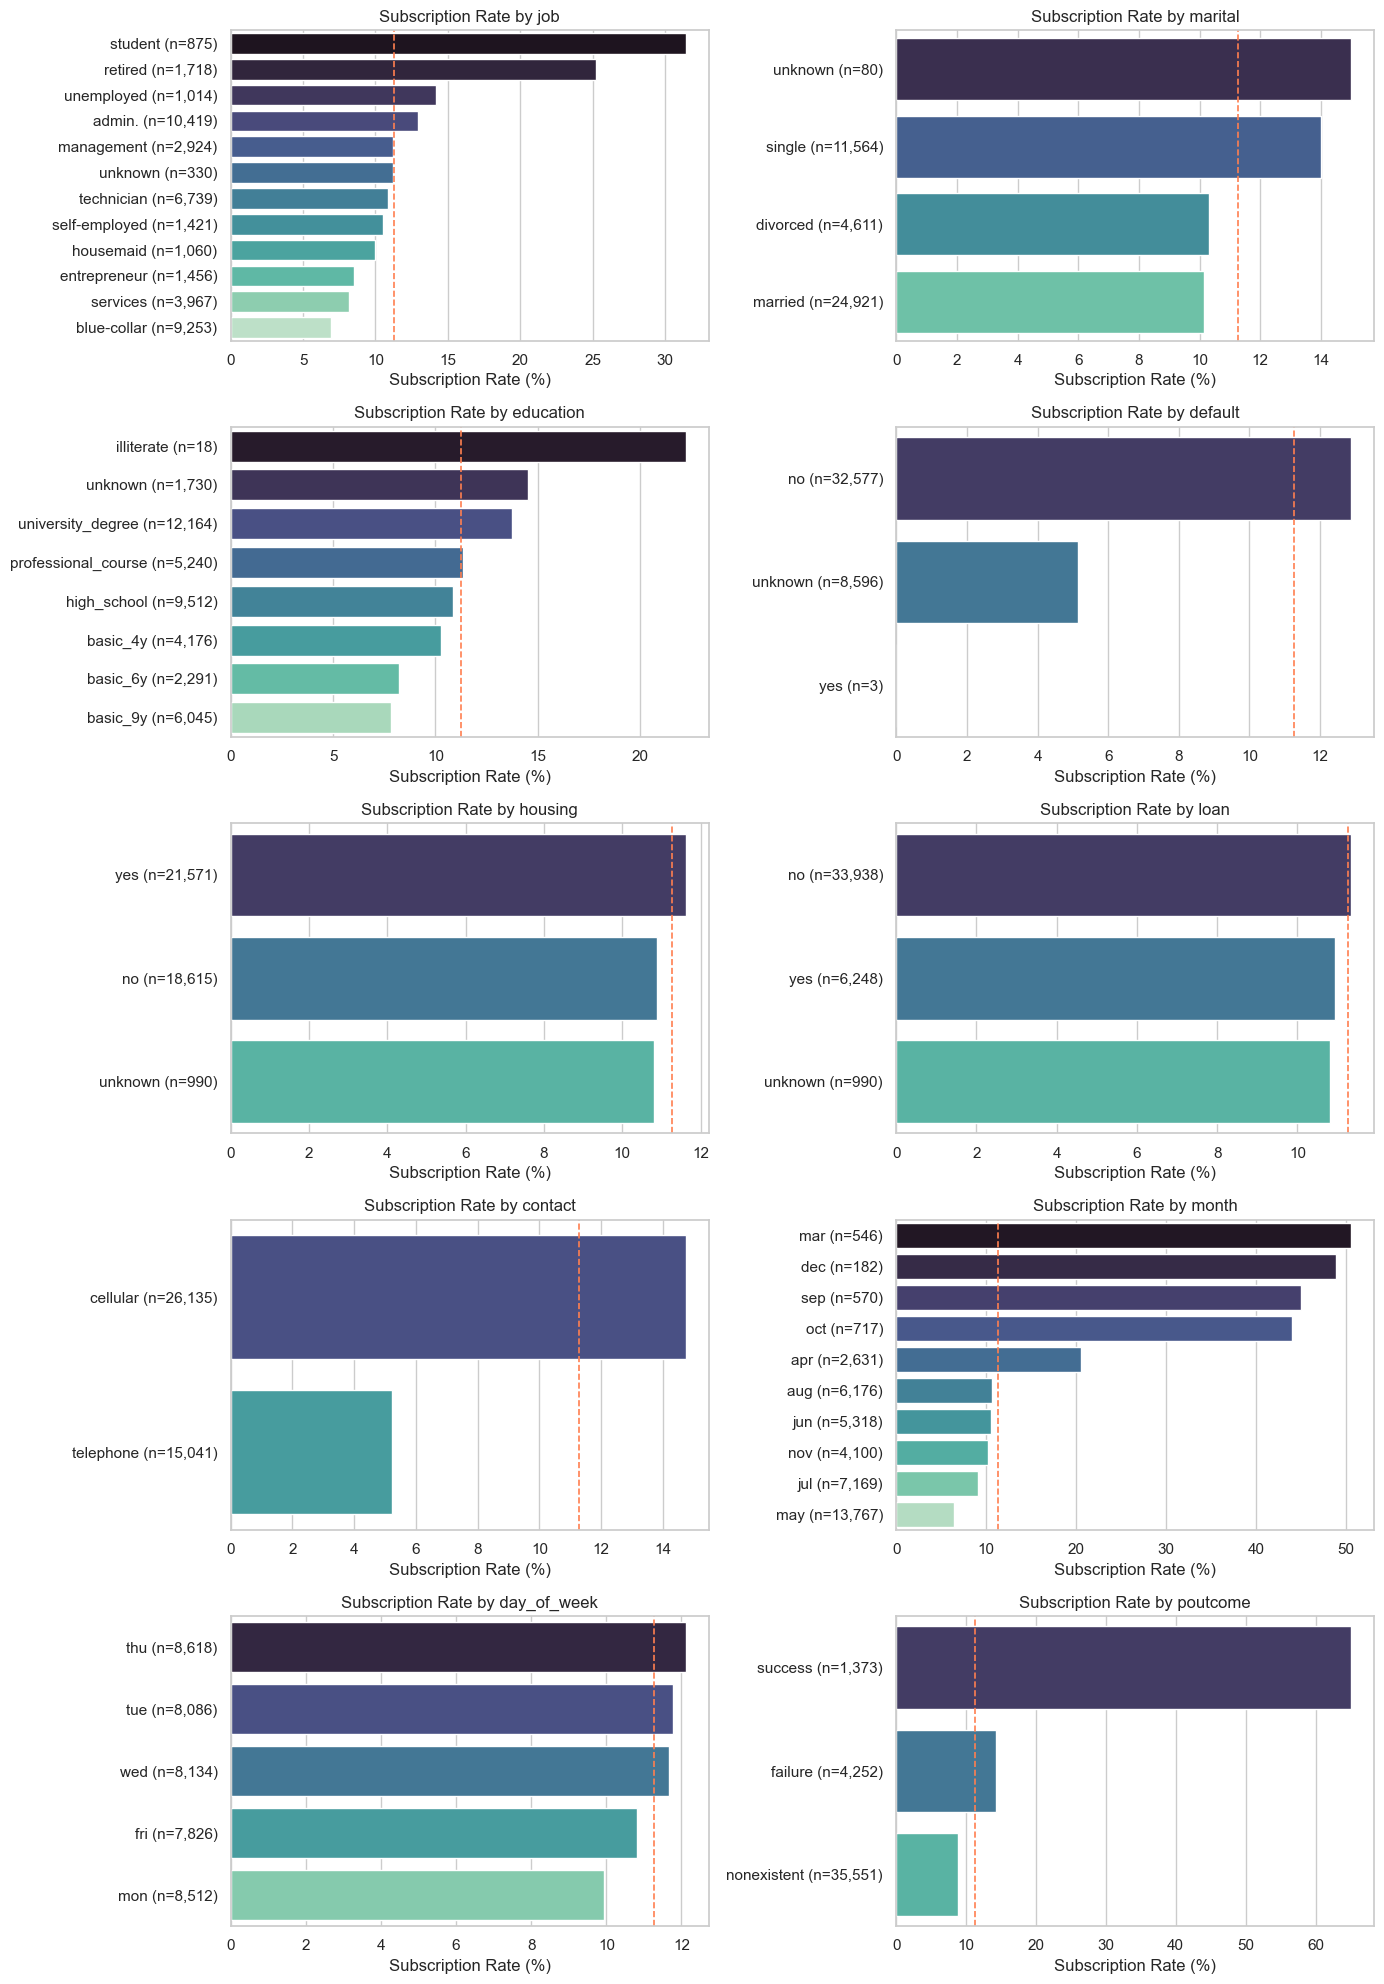

In [112]:
baseline = df['subscribed'].mean() * 100

fig, axes = plt.subplots(5, 2, figsize=(14,20))
for ax, col in zip(axes.flat, object_cols):
    measure = df.groupby(col)['subscribed'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    measure['mean'] = measure['mean'] * 100

    labels = []
    for i, n in zip(measure.index, measure['count']):
        labels.append(f'{i} (n={n:,})')
    sns.barplot(x=measure['mean'], y=labels, ax=ax, palette='mako')
    ax.axvline(baseline, color='coral', linestyle='--', linewidth=1.2)
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_xlabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()

### 4.5 Distributions of Numeric Columns

In [118]:
percentile_cols = number_cols[:-1]
for col in percentile_cols:
    print(f'........{col}..........')
    print(df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))

........age..........
count    41176.00
mean        40.02
std         10.42
min         17.00
1%          23.00
5%          26.00
25%         32.00
50%         38.00
75%         47.00
95%         58.00
99%         71.00
max         98.00
Name: age, dtype: float64
........duration..........
count    41176.00
mean       258.32
std        259.31
min          0.00
1%          11.00
5%          36.00
25%        102.00
50%        180.00
75%        319.00
95%        753.00
99%       1271.25
max       4918.00
Name: duration, dtype: float64
........campaign..........
count    41176.00
mean         2.57
std          2.77
min          1.00
1%           1.00
5%           1.00
25%          1.00
50%          2.00
75%          3.00
95%          7.00
99%         14.00
max         56.00
Name: campaign, dtype: float64
........pdays..........
count    41176.00
mean         0.22
std          1.35
min          0.00
1%           0.00
5%           0.00
25%          0.00
50%          0.00
75%          0.00
95

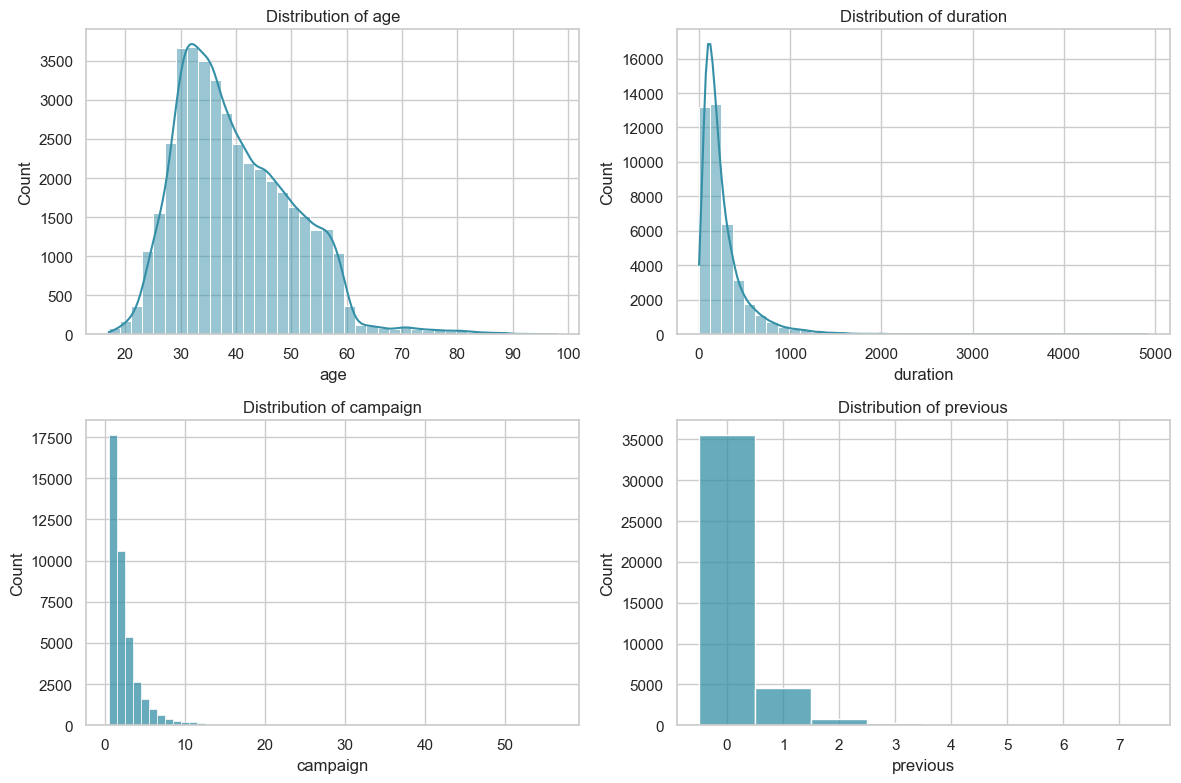

In [135]:
hist_cols = ['age', 'duration', 'campaign', 'previous']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, hist_cols):
    if  df[col].nunique() < 50:
        sns.histplot(df[col], bins=40, color=sns.color_palette('mako')[3], discrete=True, ax=ax)
    else:
        sns.histplot(df[col], bins=40, color=sns.color_palette('mako')[3], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

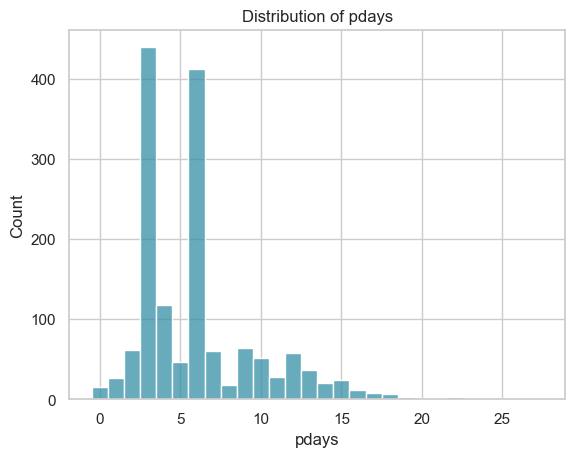

In [137]:
sns.histplot(df.loc[df['contacted_before'] ==1, 'pdays'], bins=30, discrete=True, color=sns.color_palette('mako')[3])
plt.title('Distribution of pdays')
plt.show()

### 4.6 Rates by Age, Number of Calls and Month

In [139]:
df['age_group'] = pd.cut(df['age'], bins=[16, 25, 35, 45, 55, 65, 100])
df.groupby('age_group', observed=True)['subscribed'].agg(['mean', 'count'])

,mean,count
age_group,,
"(16, 25]",0.209610,1665
"(25, 35]",0.117219,14844
"(35, 45]",0.085053,12839
"(45, 55]",0.086941,8247
"(55, 65]",0.152211,2963
"(65, 100]",0.469256,618


In [140]:
df.groupby(df['campaign'].clip(upper=10))['subscribed'].agg(['mean', 'count'])

,mean,count
campaign,,
1,0.130373,17634
2,0.114591,10568
3,0.107491,5340
4,0.093962,2650
5,0.075047,1599
6,0.076609,979
7,0.060413,629
8,0.042500,400
9,0.060071,283


In [141]:
order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df.groupby('month')['subscribed'].agg(['mean', 'count']).reindex(order).dropna()

,mean,count
month,,
mar,0.505495,546.0
apr,0.204865,2631.0
may,0.064357,13767.0
jun,0.105115,5318.0
jul,0.090389,7169.0
aug,0.106056,6176.0
sep,0.449123,570.0
oct,0.439331,717.0
nov,0.101463,4100.0


### 4.7 Hidden Missing Values ("unknown")

In [146]:
unknowns = (df == 'unknown').sum()
unknowns[unknowns > 0].sort_values(ascending=False)

default      8596
education    1730
housing       990
loan          990
job           330
marital        80
dtype: int64

## 5. Feature Preparation
### 5.1 Dropping Leakage and Helper Columns

In [148]:
df_clean = df.drop(columns=['duration', 'age_group'])
df_clean.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'subscribed', 'contacted_before'],
      dtype='object')

### 5.2 One-Hot Encoding

In [149]:
dummied_cols =['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
df_model = pd.get_dummies(df_clean, columns=dummied_cols , drop_first=False, dtype=int)
df_model.head()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed,contacted_before,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic_4y,education_basic_6y,education_basic_9y,education_high_school,education_illiterate,education_professional_course,education_university_degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
1,57,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
2,37,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
3,40,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
4,56,1,0,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0


### 5.3 Train/Test Split

In [150]:
from sklearn.model_selection import train_test_split
X = df_model.drop(columns='subscribed')
y = df_model['subscribed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 5.4 Class Imbalance Weight

In [152]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count
scale_pos_weight

np.float64(7.876313662085691)

## 6. Modelling
### 6.1 Building the Three Models

In [156]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [159]:
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced')
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [160]:
rf = RandomForestClassifier(max_depth=8, class_weight='balanced', n_estimators=300, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [161]:
xgb = XGBClassifier(
    max_depth=4, class_weight='balanced', n_estimators=300, n_jobs=-1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', learning_rate=0.05)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


### 6.2 First Look: Test-Set Scores (Exploratory)

In [162]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [163]:
models =[('Decision Tree', dt), ('Random Forest', rf), ('XGBoost', xgb)]
auc_scores = {}
for name, model in models:
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, probability)
    auc_scores[name] = auc

    print(f'........{name}.........')
    print(classification_report(y_test, prediction))
    print('ROC_AUC:', round(auc, 2))

........Decision Tree.........
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7308
           1       0.39      0.62      0.48       928

    accuracy                           0.85      8236
   macro avg       0.67      0.75      0.69      8236
weighted avg       0.88      0.85      0.86      8236

ROC_AUC: 0.79
........Random Forest.........
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7308
           1       0.40      0.64      0.49       928

    accuracy                           0.85      8236
   macro avg       0.67      0.76      0.70      8236
weighted avg       0.89      0.85      0.87      8236

ROC_AUC: 0.81
........XGBoost.........
              precision    recall  f1-score   support

           0       0.95      0.86      0.91      7308
           1       0.38      0.66      0.48       928

    accuracy                           0.84      8236
   macro avg 

### 6.3 Cross-Validated Comparison

In [167]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [169]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models:
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=['average_precision', 'roc_auc'])
    pr = s['test_average_precision']
    roc = s['test_roc_auc']
    print(f'........{name}.........')
    print(f'PR-AUC: {pr.mean():.3f} (±{pr.std():.3f}) | ROC-AUC {roc.mean():.3f}')

........Decision Tree.........
PR-AUC: 0.385 (±0.005) | ROC-AUC 0.774
........Random Forest.........
PR-AUC: 0.460 (±0.017) | ROC-AUC 0.797
........XGBoost.........
PR-AUC: 0.465 (±0.015) | ROC-AUC 0.799


### 6.4 Hyperparameter Tuning (XGBoost)

In [170]:
from sklearn.model_selection import GridSearchCV
parameters = {
    'max_depth': [3, 5, 7],
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 3, scale_pos_weight]
}
grid = GridSearchCV(xgb, parameters, cv=cv, scoring='average_precision', n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_, round(grid.best_score_, 3))

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1} 0.466


## 7. Final Evaluation
### 7.1 Test-Set Performance

In [171]:
from sklearn.metrics import average_precision_score
final = grid.best_estimator_
prediction = final.predict(X_test)
probability = final.predict_proba(X_test)[:,1]

print(classification_report(y_test, prediction))
print('ROC-AUC:', round(roc_auc_score(y_test, probability), 3))
print('PR-AUC:', round(average_precision_score(y_test, probability), 3))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7308
           1       0.64      0.23      0.33       928

    accuracy                           0.90      8236
   macro avg       0.78      0.61      0.64      8236
weighted avg       0.88      0.90      0.88      8236

ROC-AUC: 0.812
PR-AUC: 0.485


### 7.2 Business View: Lift

In [173]:
results = pd.DataFrame({'actual': y_test.values, 'prob': probability})
results = results.sort_values('prob', ascending=False).reset_index(drop=True)

total_yes = results['actual'].sum()
for pct in [0.1, 0.2, 0.3, 0.5]:
    top = results.head(int(len(results) * pct))
    captured = top['actual'].sum() / total_yes
    print(f'Call the top {pct:.0%} of clients -------> reach {captured:.0%} of subscribers (lift {captured/pct:.1f}x)')

Call the top 10% of clients -------> reach 46% of subscribers (lift 4.6x)
Call the top 20% of clients -------> reach 67% of subscribers (lift 3.3x)
Call the top 30% of clients -------> reach 74% of subscribers (lift 2.5x)
Call the top 50% of clients -------> reach 84% of subscribers (lift 1.7x)


### 7.3 Feature Importance

In [181]:
importances = pd.Series(final.feature_importances_, index = X_train.columns).sort_values(ascending=False)
pd.set_option('display.max_rows', None)
importances.head(15)

nr_employed           0.363443
contacted_before      0.217510
poutcome_success      0.077152
emp_var_rate          0.063751
month_oct             0.031315
cons_conf_idx         0.028103
month_may             0.023953
poutcome_failure      0.013770
contact_cellular      0.012023
pdays                 0.010517
euribor3m             0.009623
default_no            0.007601
cons_price_idx        0.007177
job_self-employed     0.006553
education_basic_4y    0.006397
dtype: float32

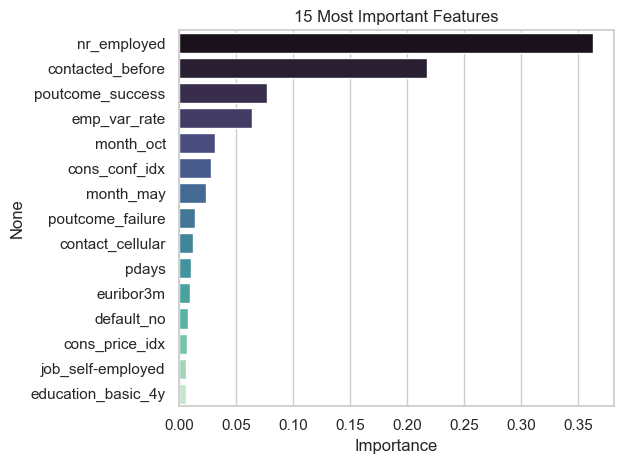

In [183]:
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='mako')
plt.title('15 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Conclusions and Limitations

**Result**
- Final model: tuned XGBoost, trained without `duration`. Test PR-AUC **0.485** (random guessing ≈ 0.113), ROC-AUC **0.812**.
- Calling the top 20% of clients, ranked by the model, reaches **67%** of all subscribers (3.3x better than calling at random).

**Key findings**
- Clients whose previous campaign succeeded subscribed **65.1%** of the time, versus 8.8% for clients never contacted before.
- The five economic columns make up about **47%** of the model's feature importance, with `nr_employed` alone at 36.3%.
- Age has a U-shape that correlation misses: 65+ subscribed 46.9% and under-25s 21.0%, against 8.5-8.7% for ages 35-55, even though the linear correlation with age is only 0.03.
- Cellular calls converted at 14.7% versus 5.2% for telephone calls.
- `duration` was excluded because call length is only known after the call, so it would leak the answer.

**Limitations**
- These are associations, not causes.
- The economic indicators are shared by everyone called in the same period, so the model may partly learn *when* a call happened. The split was random and not tested on later periods.
- Tuning added almost nothing (CV PR-AUC 0.465 → 0.466), and at the default cutoff the model catches only 23% of subscribers.
- Very small groups (`illiterate`, `marital = unknown`, `default = yes`) were not interpreted.